In [1]:
import pandas as pd
import glob
import numpy as np



In [6]:
df = pd.read_csv('MIC_data_original.csv')
print("Initial shape:", df.shape)

# 2. Look at columns
print(df.columns)

print("Unique values", df.nunique())


Initial shape: (188575, 13)
Index(['Peptide ID', 'Peptide Sequence', 'Target Species', 'Activity Measure',
       'Activity', 'Unit', 'pH', 'Ionic Strength mM', ' "Salt Type"', 'Medium',
       'CFU', 'Note', 'Reference'],
      dtype='object')
Unique values Peptide ID           23771
Peptide Sequence     20439
Target Species        8057
Activity Measure      1576
Activity             12706
Unit                     4
pH                     107
Ionic Strength mM      449
 "Salt Type"           422
Medium                 143
CFU                    167
Note                  6864
Reference               80
dtype: int64


We can see there are 20,439 unique peptides, 8,057 unique strains being tested against, and only 80 references, which means many peptides may share the same paper source. 

Now, we do some basic dataset cleaning, dropping some columns and dropping missing data, data that does not measure MIC, and complete duplicates

In [58]:
import numpy as np

# keep only relevant columns
cleaned_df = df[[
    "Peptide Sequence",
    "Target Species",
    "Activity Measure",
    "Activity",
    "Unit",
    "Reference"
]].copy()

# remove missing from 188575 to 177258
cleaned_df = cleaned_df.dropna()

#remove other measurement values such as MBC, IC50, LC, MIC50  from 177258 to 135441              
cleaned_df = cleaned_df[cleaned_df["Activity Measure"] == "MIC"]

# question: should i remove modified  from 135441 to 97970
#df = df[df["Peptide Sequence"].str.match("^[ACDEFGHIKLMNPQRSTVWY]+$", na=False)]

# length filter from 97970 to 89765
#df["length"] = df["Peptide Sequence"].str.len()
#df = df[(df["length"] >= 8) & (df["length"] <= 50)]


#FOR NOW: removed range data 16-32, >200 from 89765 to 63532
#df = df[df["Activity"].astype(str).str.match("^[0-9.]+$", na=False)]

# drop duplicates from 63532 to 61715
cleaned_df = cleaned_df.drop_duplicates()

print("dropped rows", df.shape[0] - cleaned_df.shape[0])
print("newshape", cleaned_df.shape[0])
#print(removed.shape)

dropped rows 60372
newshape 128203


In [61]:
print(cleaned_df.groupby('Unit')['Activity'].value_counts().groupby(level=0).head(5))
print(cleaned_df['Activity'].unique())
ranges = cleaned_df['Activity'].astype(str).str.contains('-').sum()
thresholded = cleaned_df['Activity'].astype(str).str.contains('>|<').sum()

print(f"Range values (with -): {ranges}")
print(f"Thresholded values (> or <): {thresholded}")

top5_counts = cleaned_df.groupby('Unit')['Activity'].value_counts().groupby(level=0).head(5)
total_counts = cleaned_df.groupby('Unit')['Activity'].count()

top5_sum = top5_counts.groupby(level=0).sum()
ratio = top5_sum / total_counts

print("Top 5 activity values as fraction of total, by unit:")
print(ratio)

thresholded_counts = cleaned_df[cleaned_df['Activity'].astype(str).str.contains('>|<', na=False)]['Activity'].value_counts()
print(thresholded_counts)

Unit   Activity
µM     4           3804
       8           3782
       16          3101
       2           2856
       32          2448
µg/ml  8           4096
       16          3866
       32          3271
       4           3151
       >128        2528
Name: count, dtype: int64
['1.5' '7.5' '15' ... '12.58' '25.68' '63-125']
Range values (with -): 6742
Thresholded values (> or <): 26707
Top 5 activity values as fraction of total, by unit:
Unit
µM       0.239025
µg/ml    0.275880
dtype: float64
Activity
>128        4807
>100        3835
>64         3398
>50         1955
>32         1531
            ... 
>214.4         1
256->256       1
>63            1
>40000         1
>19.78         1
Name: count, Length: 646, dtype: int64


Clearly, there is some thresholding going on for activity measurementss going on for the two units of activity.  

We now convert ug/mL to also be in uM. We also do some naive extreme value handling, setting . Some other strategies include taking the mean of the interval,  choosing a larger value for the high threshold, using a survival-analysis style model. 

For simplicity for now, we remove range values, and choose the threshold for thresholded data.

In [44]:
def convert_thresholded(val):
    val = str(val).strip()
    if val.startswith('>') or val.startswith('<'):
        return pd.to_numeric(val[1:], errors='coerce')
    return pd.to_numeric(val, errors='coerce')

# convert threshold, then only work on rows with numeric Activity
cleaned_df['Activity'] = cleaned_df['Activity'].apply(convert_thresholded)
cleaned_df = cleaned_df[cleaned_df["Activity"].astype(str).str.match("^[0-9.]+$", na=False)].copy()
cleaned_df["Activity"] = cleaned_df["Activity"].astype(float)

In [46]:
df_conv.shape

(96502, 8)

Now, we convert ug/ml to uM to get consistent units. 

In [48]:
from Bio.SeqUtils import molecular_weight
from Bio.Seq import Seq

def peptide_mw(seq):
    try:
        return molecular_weight(Seq(seq), seq_type='protein')
    except Exception:
        return None

df_conv = cleaned_df.copy()

# only work on rows with numeric Activity
df_conv["MW"] = df_conv["Peptide Sequence"].apply(peptide_mw)

# drop rows where MW couldn't be calculated
df_conv = df_conv[df_conv["MW"].notna() & (df_conv["MW"] > 0)]

# convert µg/ml → µM; keep µM rows as-is
df_conv["Activity_uM"] = df_conv.apply(
    lambda row: (row["Activity"] / row["MW"]) * 1000
    if row["Unit"].strip() == "µg/ml"
    else row["Activity"],
    axis=1
)

print(df_conv["Unit"].value_counts())
print(df_conv[["Peptide Sequence", "Activity", "Unit", "MW", "Activity_uM"]].head(10))

df_conv = df_conv[df_conv["Peptide Sequence"].str.len() >= 6]
print(df_conv.shape[0])

Unit
µM       54220
µg/ml    42282
Name: count, dtype: int64
            Peptide Sequence  Activity Unit         MW  Activity_uM
0  FLGLIFHGLVHAGKLIHGLIHRNRG       1.5   µM  2776.2926          1.5
1  FLGLIFHGLVHAGKLIHGLIHRNRG       7.5   µM  2776.2926          7.5
2  FLGLIFHGLVHAGKLIHGLIHRNRG       7.5   µM  2776.2926          7.5
3  FLGLIFHGLVHAGKLIHGLIHRNRG      15.0   µM  2776.2926         15.0
4  FLGLIFHGLVHAGKLIHGLIHRNRG      48.0   µM  2776.2926         48.0
5  FLGLIFHGLVHAGKLIHGLIHRNRG       3.0   µM  2776.2926          3.0
6  FLGLIFHGLVHAGKLIHGLIHRNRG       6.0   µM  2776.2926          6.0
7  FLGLIFHGLVHAGKLIHGLIHRNRG       7.5   µM  2776.2926          7.5
8  FLGLIFHGLVHAGKLIHGLIHRNRG      12.0   µM  2776.2926         12.0
9  FLGLIFHGLVHAGKLIHGLIHRNRG      15.0   µM  2776.2926         15.0
92658


In [ ]:
df.to_csv('MIC_data_cleaned.csv', index=False)

We begin some visualizations. We can see the MIC looks normally centered around 3, with some of the thresholding obvious. The length is tailed, but with most of it concentrated around 15-20 peptides. Longer peptides seem to be slightly more powerful. 


We can also see that some labs log the generic version of the bacteria instead of the specific. 

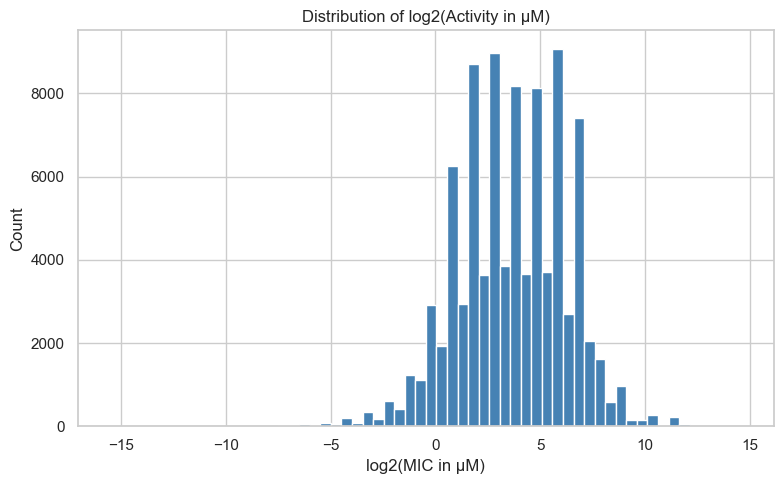

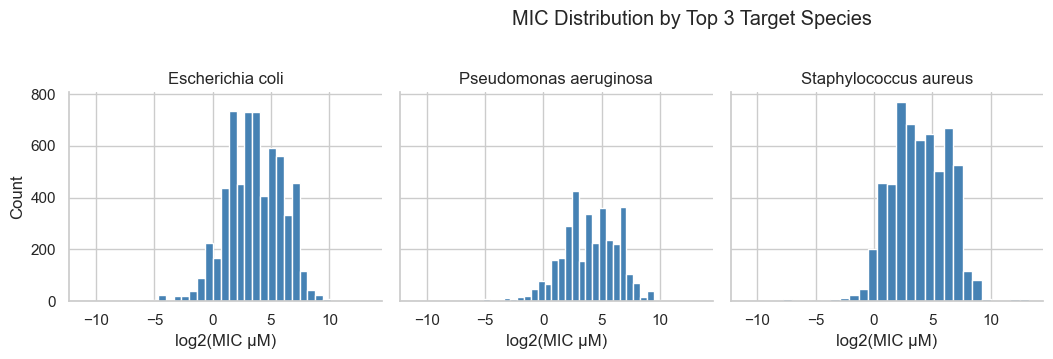

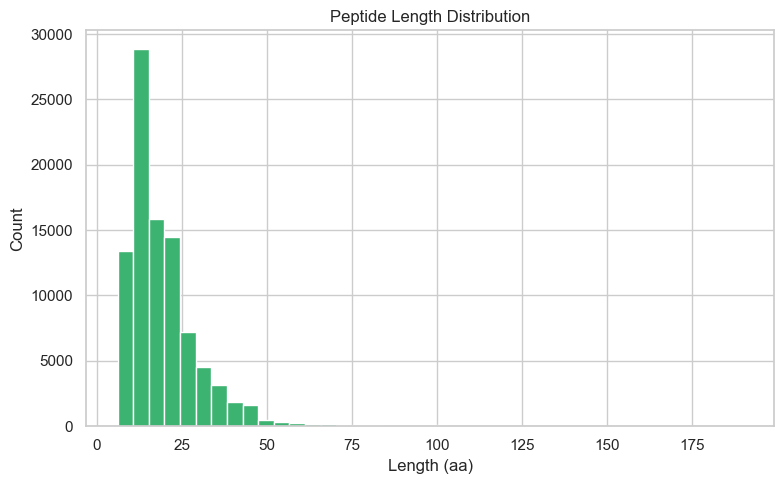

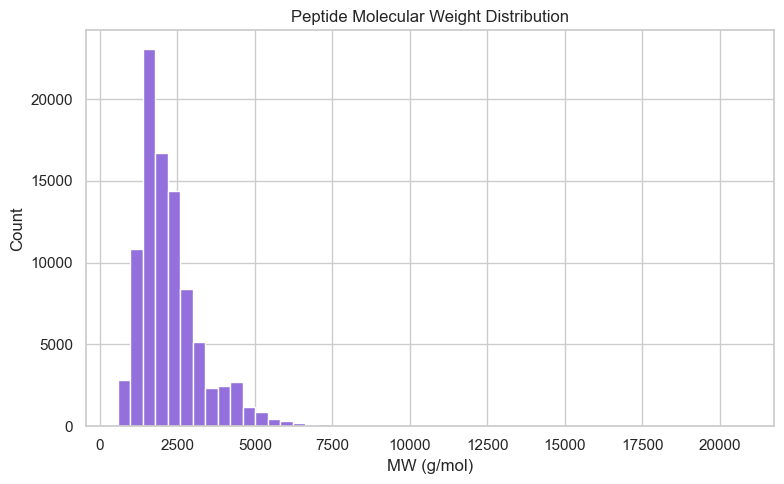

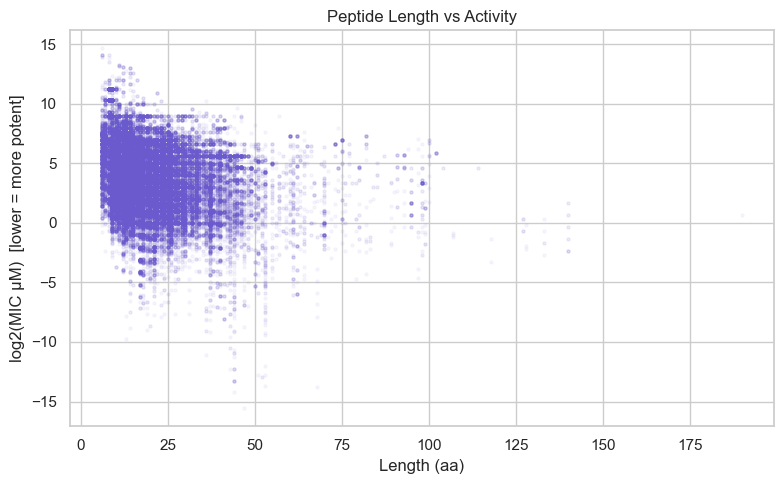

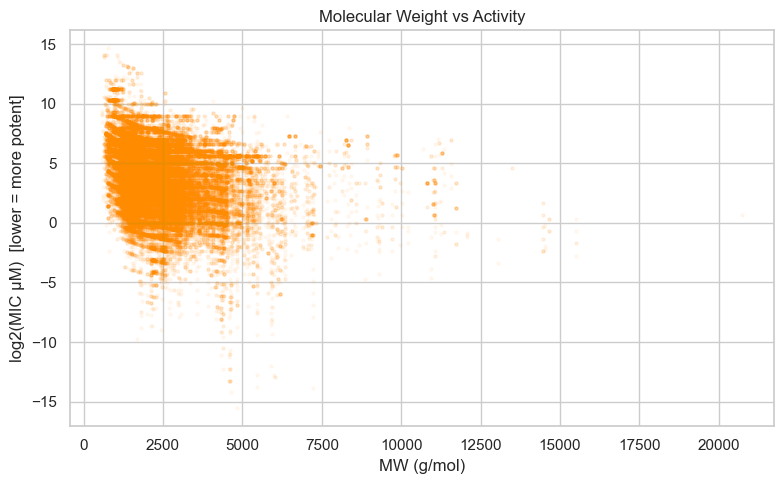

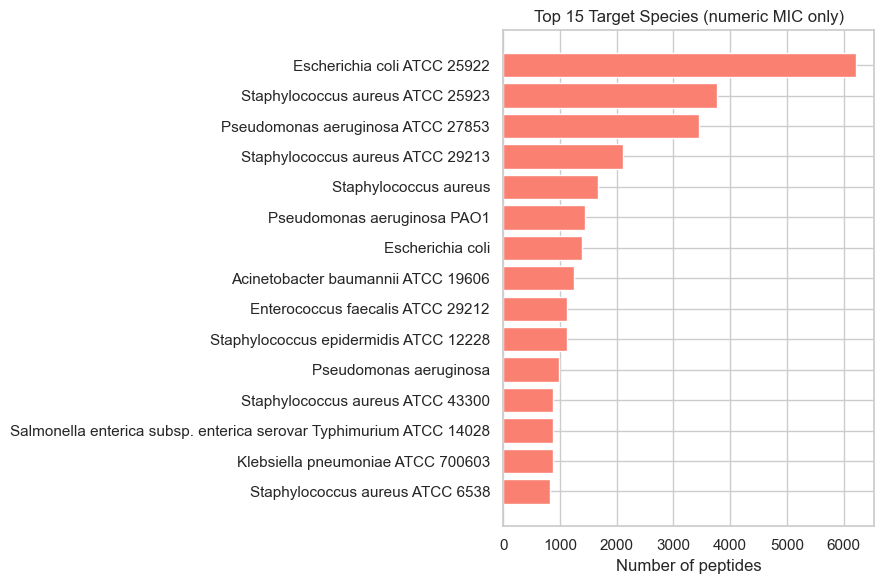

/var/folders/7p/h8pns05173zdh9cxtvc_p_n80000gn/T/ipykernel_67047/1586838279.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_top10, y="Target Species", x="log2_Activity_uM", order=order, palette="coolwarm")


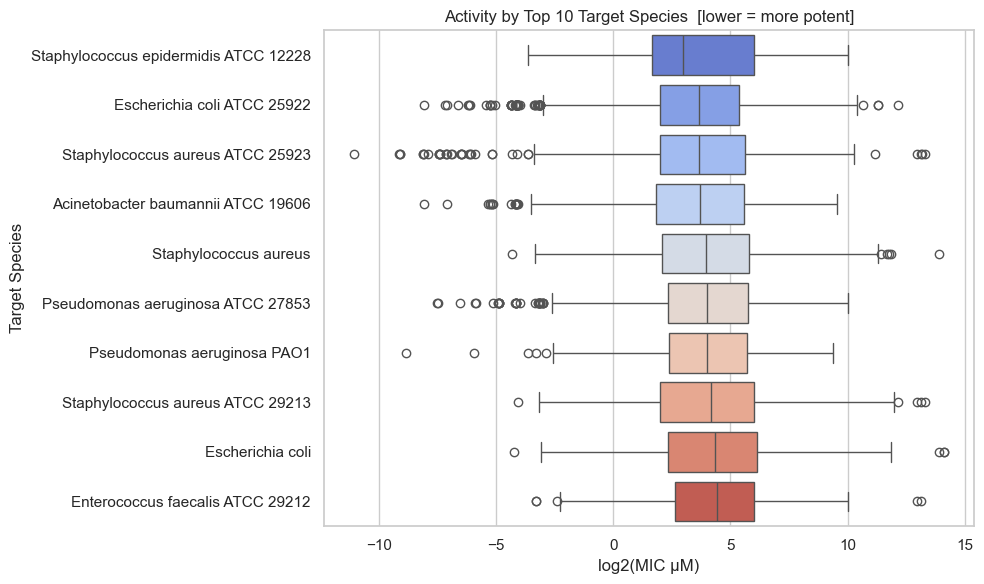

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

viz = df_conv.copy()
viz["log2_Activity_uM"] = np.log2(viz["Activity_uM"])
sns.set_theme(style="whitegrid")

# 1. Target variable: log2(Activity_uM) distribution
plt.figure(figsize=(8, 5))
plt.hist(viz["log2_Activity_uM"], bins=60, color="steelblue", edgecolor="white")
plt.title("Distribution of log2(Activity in µM)")
plt.xlabel("log2(MIC in µM)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

#plot for top species
top_species = viz["Target Species"].value_counts().head(4).index
df_top = viz[viz["Target Species"].isin(top_species)].copy()
df_top["Species (short)"] = df_top["Target Species"].str.replace(r" ATCC.*", "", regex=True)

g = sns.FacetGrid(df_top, col="Species (short)", col_wrap=4, height=3.5, sharey=True)
g.map(plt.hist, "log2_Activity_uM", bins=30, color="steelblue", edgecolor="white")
g.set_axis_labels("log2(MIC µM)", "Count")
g.set_titles("{col_name}")
plt.suptitle("MIC Distribution by Top 3 Target Species", y=1.02)
plt.tight_layout()
plt.show()

# 2. Peptide length distribution
viz["length"] = viz["Peptide Sequence"].str.len()
plt.figure(figsize=(8, 5))
plt.hist(viz["length"], bins=40, color="mediumseagreen", edgecolor="white")
plt.title("Peptide Length Distribution")
plt.xlabel("Length (aa)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# 3. Molecular weight distribution
plt.figure(figsize=(8, 5))
plt.hist(viz["MW"], bins=50, color="mediumpurple", edgecolor="white")
plt.title("Peptide Molecular Weight Distribution")
plt.xlabel("MW (g/mol)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# 4. Length vs log2(Activity_uM)
plt.figure(figsize=(8, 5))
plt.scatter(viz["length"], viz["log2_Activity_uM"], alpha=0.05, s=5, color="slateblue")
plt.title("Peptide Length vs Activity")
plt.xlabel("Length (aa)")
plt.ylabel("log2(MIC µM)  [lower = more potent]")
plt.tight_layout()
plt.show()

# 5. MW vs log2(Activity_uM)
plt.figure(figsize=(8, 5))
plt.scatter(viz["MW"], viz["log2_Activity_uM"], alpha=0.05, s=5, color="darkorange")
plt.title("Molecular Weight vs Activity")
plt.xlabel("MW (g/mol)")
plt.ylabel("log2(MIC µM)  [lower = more potent]")
plt.tight_layout()
plt.show()

# 6. Top 15 target species
plt.figure(figsize=(9, 6))
top_species = viz["Target Species"].value_counts().head(15)
plt.barh(top_species.index[::-1], top_species.values[::-1], color="salmon")
plt.title("Top 15 Target Species (numeric MIC only)")
plt.xlabel("Number of peptides")
plt.tight_layout()
plt.show()

# 7. Median potency per top 10 species
plt.figure(figsize=(10, 6))
top10 = viz["Target Species"].value_counts().head(10).index
df_top10 = viz[viz["Target Species"].isin(top10)]
order = df_top10.groupby("Target Species")["log2_Activity_uM"].median().sort_values().index
sns.boxplot(data=df_top10, y="Target Species", x="log2_Activity_uM", order=order, palette="coolwarm")
plt.title("Activity by Top 10 Target Species  [lower = more potent]")
plt.xlabel("log2(MIC µM)")
plt.tight_layout()
plt.show()


In [32]:
# 1. Repeat tests for same peptide–strain combo
combo_counts = viz.groupby(["Peptide Sequence", "Target Species"]).size()
print("=== Repeat tests per peptide–species combo ===")
print(combo_counts.describe())
print(f"Combos tested >1 time: {(combo_counts > 1).sum()}")

# 2. Tests per bacteria (strain)
strain_counts = viz.groupby("Target Species").size().sort_values(ascending=False)
print("\n=== Tests per target species ===")
print(strain_counts.head(10))

# 3. Tests per peptide
peptide_counts = viz.groupby("Peptide Sequence").size().sort_values(ascending=False)
print("\n=== Tests per peptide ===")
print(peptide_counts.describe())
print(f"Peptides tested only once: {(peptide_counts == 1).sum()}")
print(f"Peptides tested 10+ times: {(peptide_counts >= 10).sum()}")

=== Repeat tests per peptide–species combo ===
count    86446.000000
mean         1.116327
std          0.526494
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         23.000000
dtype: float64
Combos tested >1 time: 6326

=== Tests per target species ===
Target Species
Escherichia coli ATCC 25922              6463
Staphylococcus aureus ATCC 25923         3973
Pseudomonas aeruginosa ATCC 27853        3544
Staphylococcus aureus ATCC 29213         2187
Staphylococcus aureus                    1731
Pseudomonas aeruginosa PAO1              1473
Escherichia coli                         1412
Acinetobacter baumannii ATCC 19606       1310
Enterococcus faecalis ATCC 29212         1190
Staphylococcus epidermidis ATCC 12228    1172
dtype: int64

=== Tests per peptide ===
count    13494.000000
mean         7.151475
std          7.762761
min          1.000000
25%          3.000000
50%          5.000000
75%          9.000000
max        142.000000
dtype: fl

Clearly, there are some outliers in the amount of tests for the top-tested bacteria strains. So we also truncate and look at the distribution for the majority of the strains. 

We plot the histograms for individual test combinations and peptide tests as well, and we see that the majority are tested only once or a few times. 

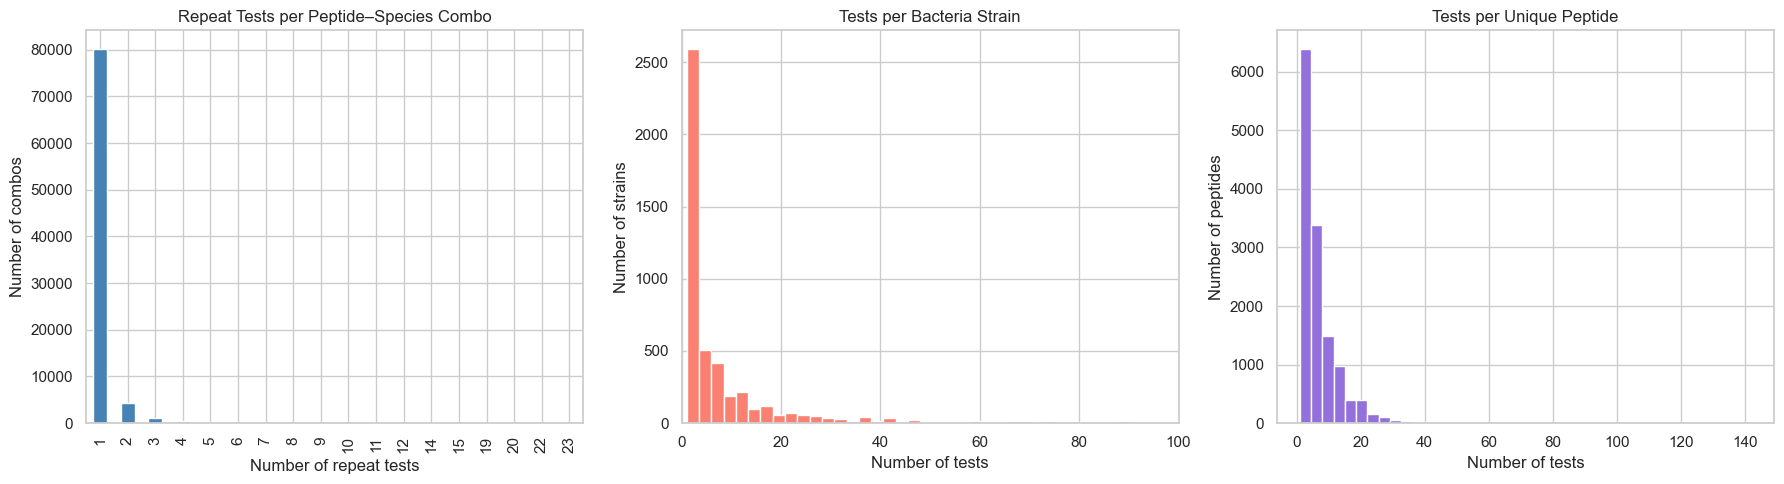

Total peptide–species combos: 86446
Combos tested exactly once: 80120
Combos tested more than once: 6326
Total repeat measurements: 10056


In [40]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Repeat tests per peptide–species combo (distribution)
combo_counts.value_counts().sort_index().head(20).plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='white'
)
axes[0].set_title("Repeat Tests per Peptide–Species Combo")
axes[0].set_xlabel("Number of repeat tests")
axes[0].set_ylabel("Number of combos")

# 2. Tests per bacteria strain (binned distribution), cutting off largest balues
axes[1].hist(strain_counts[strain_counts <= 100].values, bins=40, color='salmon', edgecolor='white')
axes[1].set_xlim(0, 100)
axes[1].set_title("Tests per Bacteria Strain")
axes[1].set_xlabel("Number of tests")
axes[1].set_ylabel("Number of strains")

# 3. Tests per peptide (binned distribution)
axes[2].hist(peptide_counts.values, bins=40, color='mediumpurple', edgecolor='white')
axes[2].set_title("Tests per Unique Peptide")
axes[2].set_xlabel("Number of tests")
axes[2].set_ylabel("Number of peptides")

plt.tight_layout()
plt.show()

combo_counts = viz.groupby(["Peptide Sequence", "Target Species"]).size()
print(f"Total peptide–species combos: {len(combo_counts)}")
print(f"Combos tested exactly once: {(combo_counts == 1).sum()}")
print(f"Combos tested more than once: {(combo_counts > 1).sum()}")
print(f"Total repeat measurements: {(combo_counts - 1).sum()}")

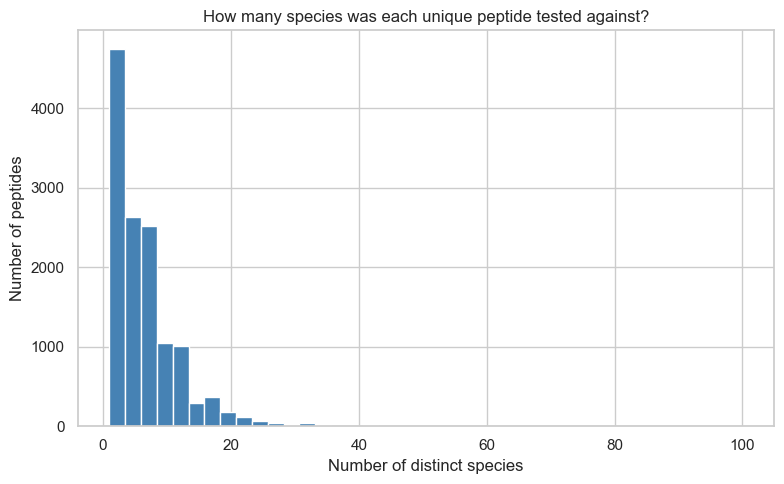

INTERPRETATION: A heavy spike at 1 means most peptides were tested against only one species
— good for diversity but makes cross-species generalisation harder.
  Median: 5  |  Max: 100


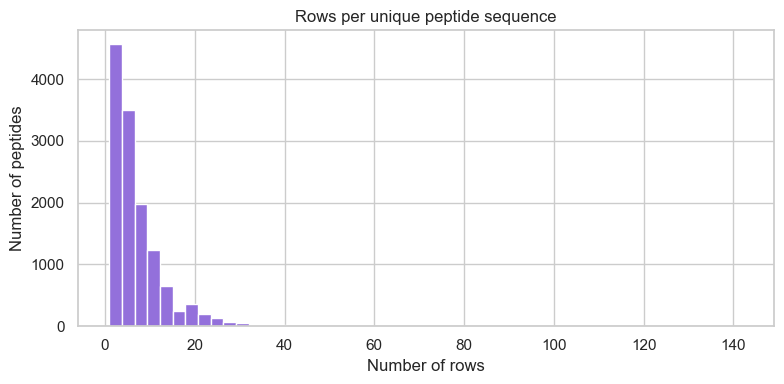

INTERPRETATION: A long right tail means a few peptides dominate the dataset.
If the top peptides are also in your test set, your model will look better than it is.
  Top 4 most-repeated peptides (row counts): [142, 134, 131, 121]


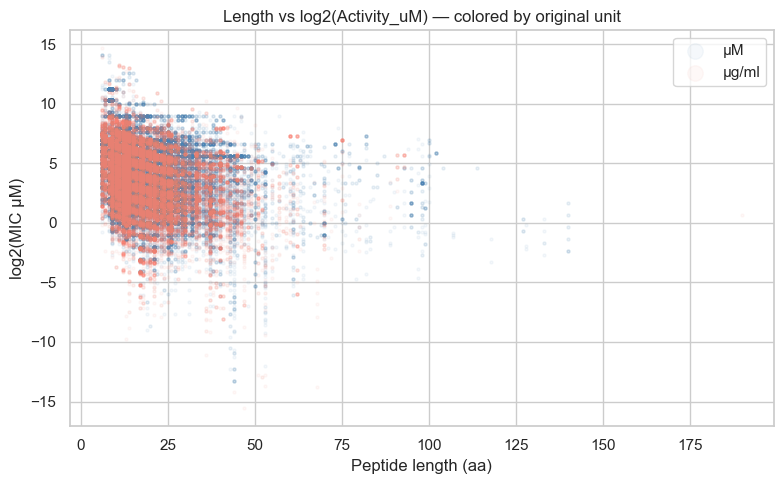

INTERPRETATION: The two unit groups should overlap naturally.
If µg/ml points cluster in a completely separate band, the conversion may be off
(e.g. MW calculation errors or the source data used a different µg/ml definition).


/var/folders/7p/h8pns05173zdh9cxtvc_p_n80000gn/T/ipykernel_67047/1835141261.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=viz, x="Unit", y="log2_uM", palette="Set2")


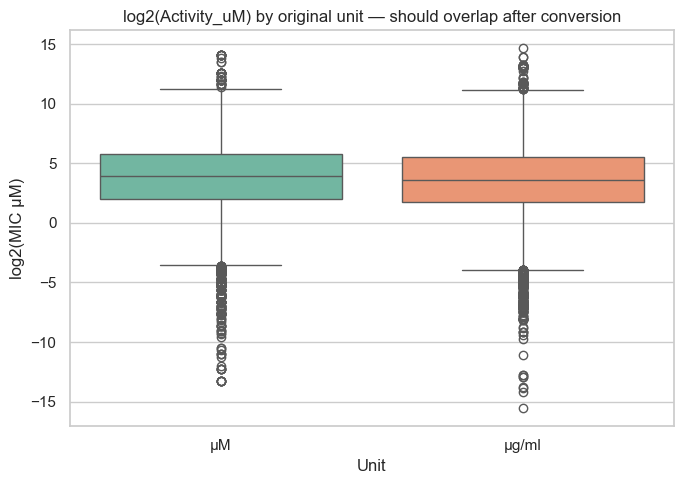

INTERPRETATION: Medians and spreads should be broadly similar after unit conversion.
A large systematic offset between units suggests the conversion introduced a bias.


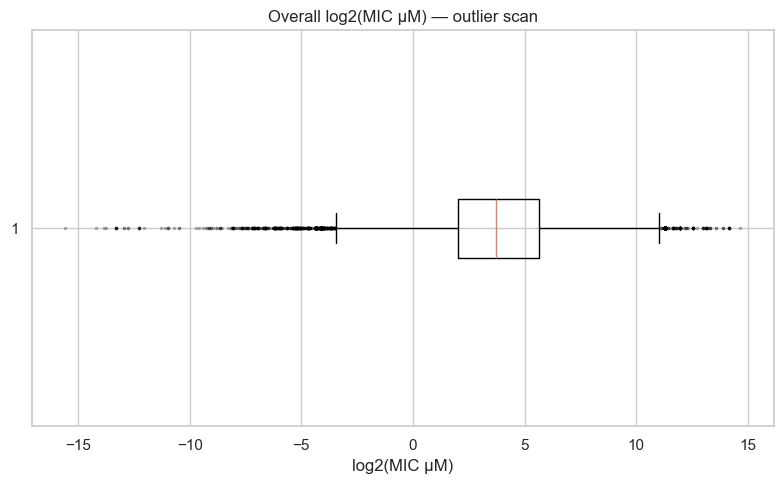

INTERPRETATION: Points beyond 3×IQR are likely data entry errors.
  39 extreme outliers found (0.04% of rows)
  IQR range: [2.0, 5.6]  |  Outlier thresholds: <-8.9 or >16.6


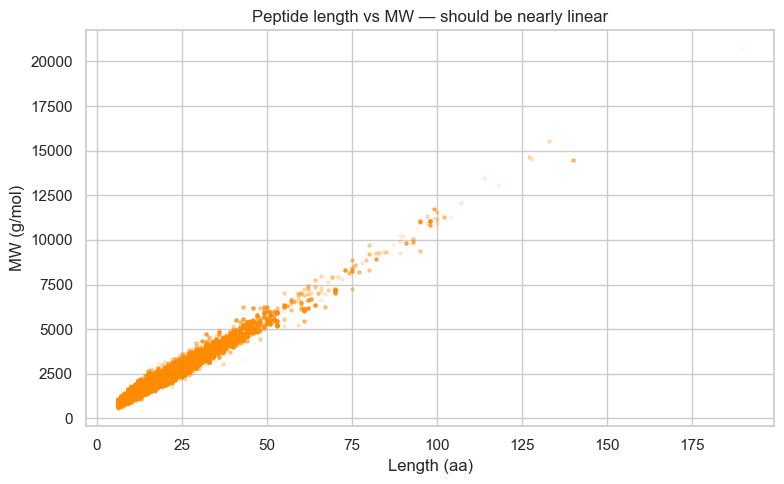

INTERPRETATION: Length and MW should be nearly perfectly correlated (r ≈ 1).
  Pearson r = 0.9818
Points far off the diagonal = unusual sequences, modified AAs, or data entry errors.


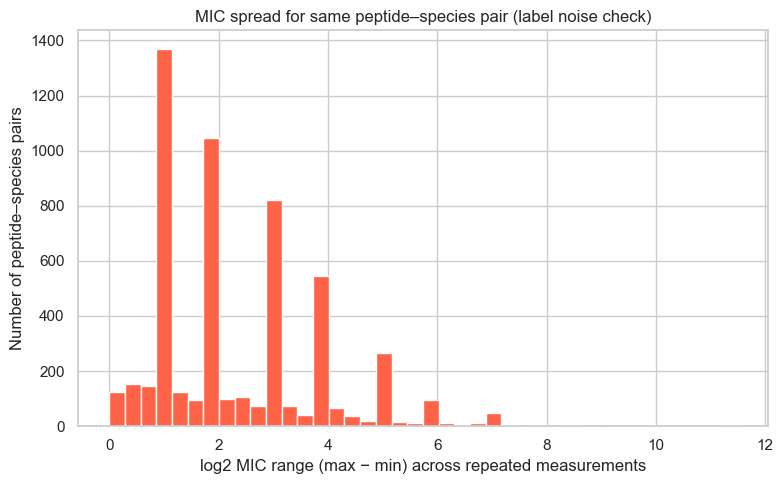

INTERPRETATION: Pairs with spread > 2 (i.e. 4-fold MIC difference) across labs
are noisy labels — the same experiment gave very different results.
  2456 peptide–species pairs have >4-fold MIC disagreement (2.9% of pairs)


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")
viz = df_conv.copy()
viz["log2_uM"] = np.log2(viz["Activity_uM"])
viz["length"] = viz["Peptide Sequence"].str.len()

# ── 1. Species tested per unique peptide ─────────────────────────────────────
species_per_pep = viz.groupby("Peptide Sequence")["Target Species"].nunique()
plt.figure(figsize=(8, 5))
plt.hist(species_per_pep, bins=40, color="steelblue", edgecolor="white")
plt.title("How many species was each unique peptide tested against?")
plt.xlabel("Number of distinct species")
plt.ylabel("Number of peptides")
plt.tight_layout()
plt.show()
print("INTERPRETATION: A heavy spike at 1 means most peptides were tested against only one species")
print("— good for diversity but makes cross-species generalisation harder.")
print(f"  Median: {species_per_pep.median():.0f}  |  Max: {species_per_pep.max()}")

# ── 2. Measurements per unique peptide ───────────────────────────────────────
rows_per_pep = viz.groupby("Peptide Sequence").size()
plt.figure(figsize=(8, 5))
plt.hist(rows_per_pep, bins=50, color="mediumpurple", edgecolor="white")
plt.title("Rows per unique peptide sequence")
plt.xlabel("Number of rows")
plt.ylabel("Number of peptides")
plt.tight_layout()
plt.show()
print("INTERPRETATION: A long right tail means a few peptides dominate the dataset.")
print("If the top peptides are also in your test set, your model will look better than it is.")
top5 = rows_per_pep.sort_values(ascending=False).head(5)
print(f"  Top 5 most-repeated peptides (row counts): {top5.values.tolist()}")

# ── 3. Activity_uM after conversion, colored by original unit ────────────────
plt.figure(figsize=(8, 5))
for unit, color in [("µM", "steelblue"), ("µg/ml", "salmon")]:
    subset = viz[viz["Unit"].str.strip() == unit]
    plt.scatter(subset["length"], subset["log2_uM"],
                alpha=0.05, s=5, label=unit, color=color)
plt.title("Length vs log2(Activity_uM) — colored by original unit")
plt.xlabel("Peptide length (aa)")
plt.ylabel("log2(MIC µM)")
plt.legend(markerscale=5)
plt.tight_layout()
plt.show()
print("INTERPRETATION: The two unit groups should overlap naturally.")
print("If µg/ml points cluster in a completely separate band, the conversion may be off")
print("(e.g. MW calculation errors or the source data used a different µg/ml definition).")

# ── 4. Box plot of log2_uM by unit after conversion ──────────────────────────
plt.figure(figsize=(7, 5))
sns.boxplot(data=viz, x="Unit", y="log2_uM", palette="Set2")
plt.title("log2(Activity_uM) by original unit — should overlap after conversion")
plt.ylabel("log2(MIC µM)")
plt.tight_layout()
plt.show()
print("INTERPRETATION: Medians and spreads should be broadly similar after unit conversion.")
print("A large systematic offset between units suggests the conversion introduced a bias.")

# ── 5. Outlier detection: overall box plot ───────────────────────────────────
plt.figure(figsize=(8, 5))
plt.boxplot(viz["log2_uM"].dropna(), vert=False, flierprops=dict(marker=".", alpha=0.3, markersize=3))
plt.title("Overall log2(MIC µM) — outlier scan")
plt.xlabel("log2(MIC µM)")
plt.tight_layout()
plt.show()
q1, q3 = viz["log2_uM"].quantile([0.25, 0.75])
iqr = q3 - q1
outliers = viz[(viz["log2_uM"] < q1 - 3*iqr) | (viz["log2_uM"] > q3 + 3*iqr)]
print(f"INTERPRETATION: Points beyond 3×IQR are likely data entry errors.")
print(f"  {len(outliers)} extreme outliers found ({100*len(outliers)/len(viz):.2f}% of rows)")
print(f"  IQR range: [{q1:.1f}, {q3:.1f}]  |  Outlier thresholds: <{q1-3*iqr:.1f} or >{q3+3*iqr:.1f}")

# ── 6. Length vs MW — should be nearly linear ────────────────────────────────
plt.figure(figsize=(8, 5))
plt.scatter(viz["length"], viz["MW"], alpha=0.05, s=5, color="darkorange")
plt.title("Peptide length vs MW — should be nearly linear")
plt.xlabel("Length (aa)")
plt.ylabel("MW (g/mol)")
plt.tight_layout()
plt.show()
corr = viz[["length", "MW"]].corr().iloc[0, 1]
print(f"INTERPRETATION: Length and MW should be nearly perfectly correlated (r ≈ 1).")
print(f"  Pearson r = {corr:.4f}")
print("Points far off the diagonal = unusual sequences, modified AAs, or data entry errors.")

# ── 7. Label noise: MIC spread for same peptide–species pair ─────────────────
spread = (viz.groupby(["Peptide Sequence", "Target Species"])["log2_uM"]
            .agg(lambda x: x.max() - x.min())
            .reset_index(name="log2_spread"))
spread_nonzero = spread[spread["log2_spread"] > 0]
plt.figure(figsize=(8, 5))
plt.hist(spread_nonzero["log2_spread"], bins=40, color="tomato", edgecolor="white")
plt.title("MIC spread for same peptide–species pair (label noise check)")
plt.xlabel("log2 MIC range (max − min) across repeated measurements")
plt.ylabel("Number of peptide–species pairs")
plt.tight_layout()
plt.show()
print(f"INTERPRETATION: Pairs with spread > 2 (i.e. 4-fold MIC difference) across labs")
print("are noisy labels — the same experiment gave very different results.")
noisy = (spread["log2_spread"] > 2).sum()
print(f"  {noisy} peptide–species pairs have >4-fold MIC disagreement ({100*noisy/len(spread):.1f}% of pairs)")
